# RE2.4 · El modelo final se carga y detecta

Demostración funcional: el `best.pt` elegido en RE2.3 se abre con `load_checkpoint` (carga
estricta), detecta sobre una grabación de prueba que no vio al entrenar y escribe una tabla de
selección de Raven; la misma tabla se contrasta con las anotaciones del equipo. Figuras y cifras
para `RE_2-4_modelo-final.tex`.

In [1]:
import json
import subprocess
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import reporte
import soundfile as sf
import torch
from matplotlib.axes import Axes
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from reporte import PROJECT_DIR, TEXT_WIDTH_IN, number, percent
from torchvision.ops import box_iou

from core.config import RUNS_DIR, P
from data import cache
from data.annotations import load_annotations
from data.raven import BEGIN, CALL, END, HIGH, LOW, SCORE, SELECTION, SPECIES
from inference.catalog import DETECTIONS_SUFFIX, output_for
from inference.predictor import predict
from models.registry import load_checkpoint
from prepare_data import JOINED_LABELS
from utils.audio import hz_to_y, mel_spectrogram, mel_to_db

OUT = reporte.out_dir("RE_2-4")
RUN = "yolo26s_v2"  # el ganador de RE2.3
DEVICE = "cpu"  # la demostración corre como en el paquete portable: sin GPU
EXPECTED_COLUMNS = [SELECTION, "View", "Channel", BEGIN, END, LOW, HIGH, SPECIES, CALL, SCORE]

In [2]:
# 1. El checkpoint se carga sin claves incompatibles (`load_state_dict(strict=True)` adentro).
checkpoint_path = RUNS_DIR / RUN / "best.pt"
loaded = load_checkpoint(checkpoint_path, device=DEVICE)
stored = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
model_keys, stored_keys = set(loaded.model.state_dict()), set(stored["state_dict"])
assert model_keys == stored_keys, model_keys ^ stored_keys
n_params = sum(p.numel() for p in loaded.model.parameters())
print(
    f"{loaded.architecture} · {len(loaded.labels)} clases · época {stored['epoch'] + 1} · "
    f"umbral de operación {loaded.operating_point} · {n_params / 1e6:.1f} M parámetros · "
    f"{len(stored_keys)} tensores, todos cargados"
)

Overriding model.yaml nc=80 with nc=25


yolo · 25 clases · época 19 · umbral de operación 0.1 · 10.0 M parámetros · 708 tensores, todos cargados


In [3]:
# 2. Una grabación de prueba con varias clases anotadas, que ningún modelo vio al entrenar.
test_sources = cache.sources(
    cache.TEST,
    len(
        torch.load(cache.split_path(cache.TEST), map_location="cpu", weights_only=True, mmap=True)[
            "boxes"
        ]
    ),
)
annotations = load_annotations()
annotations["label"] = (annotations["species"] + "/" + annotations["call_type"]).replace(
    JOINED_LABELS
)
# Sólo las anotaciones de las clases del experimento: las frases y los pares fuera de vocabulario
# no son clases del modelo (RE1.2).
in_test = annotations.loc[
    annotations["audio_path"].isin(test_sources.recordings)
    & annotations["label"].isin(loaded.labels.names)
]
by_recording = in_test.groupby("audio_path").agg(
    clases=("label", "nunique"), cajas=("label", "size")
)
by_recording["duración"] = [sf.info(p).duration for p in by_recording.index]
candidates = by_recording.loc[
    (by_recording["duración"] <= 60) & (by_recording["cajas"].between(8, 30))
]
demo_path = Path(candidates.sort_values(["clases", "cajas"], ascending=False).index[0])
demo_annotations = in_test.loc[in_test["audio_path"] == str(demo_path)].sort_values("begin_time_s")
print(
    f"{demo_path.name}: {by_recording.loc[str(demo_path), 'duración']:.0f} s · {len(demo_annotations)} anotaciones · {demo_annotations['label'].unique().tolist()}"
)

20240611_071141.wav: 30 s · 25 anotaciones · ['as/hc', 'lw/cs', 'lw/trino', 'as/bc', 'lw/vc']


In [4]:
# 3. Inferencia con la API y con la línea de comandos: la misma tabla de Raven.
table = predict(loaded, demo_path, device=DEVICE, score_threshold=loaded.operating_point or 0.5)
assert list(table.columns) == EXPECTED_COLUMNS, table.columns
table.to_csv(OUT / f"{demo_path.stem}{DETECTIONS_SUFFIX}", sep="\t", index=False)

with tempfile.TemporaryDirectory() as folder:
    copy = Path(folder) / demo_path.name
    copy.write_bytes(demo_path.read_bytes())
    command = [
        sys.executable,
        str(PROJECT_DIR / "src" / "detect.py"),
        str(copy),
        "--model",
        str(checkpoint_path),
        "--device",
        DEVICE,
    ]
    result = subprocess.run(command, capture_output=True, text=True, check=True, cwd=PROJECT_DIR)
    cli_table = pd.read_csv(output_for(copy), sep="\t")
transcript = (
    "$ uv run python src/detect.py "
    + " ".join(
        f"<carpeta>/{demo_path.name}" if a == str(copy) else a.replace(str(PROJECT_DIR) + "/", "")
        for a in command[2:]
    )
    + "\n"
    + result.stdout
    + result.stderr
)
(OUT / "detect_stdout.txt").write_text(transcript)
assert len(cli_table) == len(table)
print(transcript)
table.head(8)

$ uv run python src/detect.py <carpeta>/20240611_071141.wav --model runs/yolo26s_v2/best.pt --device cpu
Loading detection engine...
Overriding model.yaml nc=80 with nc=25
[2026-09-14 11:09:48] [INFO] [models.registry] yolo | 25 clases | época 18 | umbral 0.10 | /home/fcandia/tesis-primate/runs/yolo26s_v2/best.pt
[2026-09-14 11:09:48] [INFO] [detect] yolo26s_v2 on cpu | score >= 0.10 | 1 recordings
[2026-09-14 11:09:53] [INFO] [detect] [1/1] 20240611_071141.wav: 33 detections in 5 s -> 20240611_071141.detections.txt
[2026-09-14 11:09:53] [INFO] [detect] Done. Open each audio in Raven with its .detections.txt table



,Selection,View,Channel,Begin Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),Species,Call type,Score
0,1,Spectrogram 1,1,0.002249,3.000000,39.558479,842.885071,AS,HC,0.892030
1,2,Spectrogram 1,1,1.500000,1.913998,6440.029297,8394.166016,LW,CS,0.739042
2,3,Spectrogram 1,1,1.964630,2.480500,6543.728027,8086.413086,LW,CS,0.585067
3,4,Spectrogram 1,1,2.551703,2.907086,6363.566406,7506.694336,LW,CS,0.340519
4,5,Spectrogram 1,1,3.001655,6.000000,29.200937,951.341797,AS,HC,0.931264
5,6,Spectrogram 1,1,6.002600,8.997398,29.786522,1007.599731,AS,HC,0.922904
6,7,Spectrogram 1,1,8.174545,8.594646,6694.775879,13398.842773,LW,TRINO,0.567613
7,8,Spectrogram 1,1,9.009302,11.997809,52.241116,796.879944,AS,HC,0.769993


In [5]:
# 4. Contraste con las anotaciones: acierto a IoU ≥ 0.3 en coordenadas de la grabación (tiempo en s, frecuencia en eje mel).
def as_boxes(begin, end, low, high) -> torch.Tensor:
    y0, y1 = (torch.from_numpy(hz_to_y(v.to_numpy(dtype=float), P)) for v in (low, high))
    return torch.stack(
        [
            torch.tensor(begin.to_numpy(dtype=float)),
            y0,
            torch.tensor(end.to_numpy(dtype=float)),
            y1,
        ],
        dim=1,
    ).float()


predicted = as_boxes(table[BEGIN], table[END], table[LOW], table[HIGH])
annotated = as_boxes(
    demo_annotations["begin_time_s"],
    demo_annotations["end_time_s"],
    demo_annotations["low_freq_hz"],
    demo_annotations["high_freq_hz"],
)
iou = box_iou(predicted, annotated)
hit_annotation = (
    (iou.max(dim=0).values >= 0.3)
    if len(predicted)
    else torch.zeros(len(annotated), dtype=torch.bool)
)
hit_prediction = (
    (iou.max(dim=1).values >= 0.3)
    if len(annotated)
    else torch.zeros(len(predicted), dtype=torch.bool)
)
predicted_labels = (table[SPECIES].str.lower() + "/" + table[CALL].str.lower()).to_numpy()
same_label = [
    bool(hit_prediction[i])
    and predicted_labels[i] == demo_annotations["label"].iloc[int(iou[i].argmax())]
    for i in range(len(predicted))
]
print(
    f"{int(hit_annotation.sum())}/{len(annotated)} anotaciones encontradas · "
    f"{int(hit_prediction.sum())}/{len(predicted)} detecciones sobre una anotación · "
    f"{sum(same_label)} con la misma etiqueta"
)

17/25 anotaciones encontradas · 17/33 detecciones sobre una anotación · 17 con la misma etiqueta


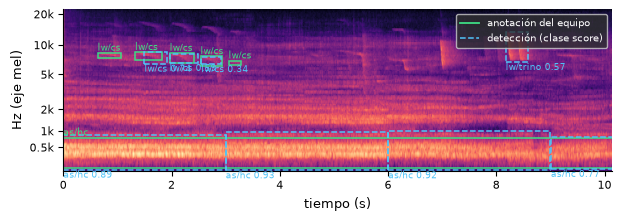

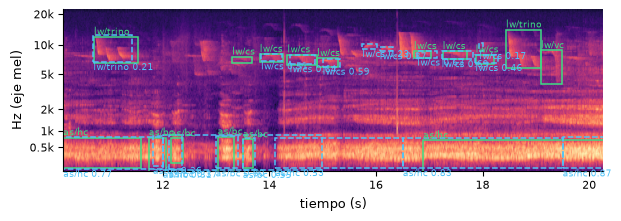

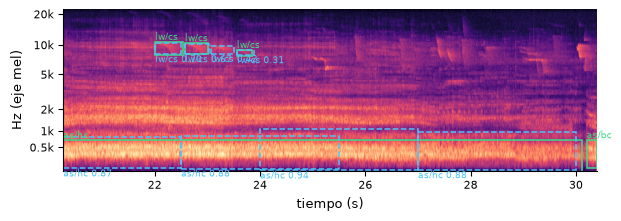

468

In [6]:
# 5. La grabación entera con las dos capas, como se ve en Raven o en el visor.
waveform, sr = sf.read(demo_path, dtype="float32", always_2d=True)
mel = mel_to_db(mel_spectrogram()(torch.from_numpy(waveform.mean(axis=1))))
duration = len(waveform) / sr


def boxes_of(frame: pd.DataFrame, columns: list[str]) -> list[tuple[float, float, float, float]]:
    return [
        (float(b), float(e), float(lo), float(hi)) for b, e, lo, hi in frame[columns].to_numpy()
    ]


ROW_SECONDS = 10.0


def draw(
    ax: Axes,
    boxes: list[tuple[float, float, float, float]],
    names: list[str],
    color: str,
    style: str,
    top: bool,
) -> None:
    t0, t1 = ax.get_xlim()
    for (begin, end, low, high), name in zip(boxes, names, strict=True):
        if end < t0 or begin > t1:
            continue
        y0, y1 = hz_to_y(np.array([low, high]), P)
        ax.add_patch(
            Rectangle((begin, y0), end - begin, y1 - y0, fill=False, ec=color, lw=1.1, ls=style)
        )
        ax.text(
            max(begin, t0),
            y1 if top else y0,
            name,
            color=color,
            fontsize=6.5,
            va="bottom" if top else "top",
        )


annotated_boxes = boxes_of(
    demo_annotations, ["begin_time_s", "end_time_s", "low_freq_hz", "high_freq_hz"]
)
annotated_names = demo_annotations["label"].astype(str).tolist()
predicted_boxes = boxes_of(table, [BEGIN, END, LOW, HIGH])
scores = table[SCORE].to_numpy(dtype=float)
predicted_names = [
    f"{name} {score:.2f}" for name, score in zip(predicted_labels, scores, strict=True)
]
ticks_hz = np.array([500.0, 1000.0, 2000.0, 5000.0, 10000.0, 20000.0])
n_rows = max(1, round(duration / ROW_SECONDS))
row_seconds = duration / n_rows  # filas iguales, sin una última fila casi vacía
frames_per_s = mel.shape[1] / duration

# Una imagen por tramo, del ancho del texto, y el bloque de subfiguras que las apila.
subfigures: list[str] = []
for row in range(n_rows):
    t0, t1 = row * row_seconds, (row + 1) * row_seconds
    fig, ax = plt.subplots(figsize=(TEXT_WIDTH_IN, 2.1), constrained_layout=True)
    ax.imshow(
        mel[:, int(t0 * frames_per_s) : int(t1 * frames_per_s)].numpy(),
        origin="lower",
        aspect="auto",
        cmap="magma",
        extent=(t0, t1, 0, 1),
    )
    ax.set_xlim(t0, t1)
    ax.grid(False)
    draw(ax, annotated_boxes, annotated_names, "#3ddc84", "-", True)
    draw(ax, predicted_boxes, predicted_names, "#4fc3f7", "--", False)
    ax.set_yticks(hz_to_y(ticks_hz, P).tolist(), [f"{f / 1000:g}k" for f in ticks_hz])
    ax.set(xlabel="tiempo (s)", ylabel="Hz (eje mel)")
    if row == 0:
        ax.legend(
            handles=[
                Line2D([], [], color="#3ddc84", lw=1.3, label="anotación del equipo"),
                Line2D([], [], color="#4fc3f7", lw=1.1, ls="--", label="detección (clase score)"),
            ],
            loc="upper right",
            fontsize=7,
            facecolor="#303030",
            labelcolor="white",
        )
    reporte.save_figure(fig, OUT / f"demo_{row + 1}")
    plt.show()
    subfigures.append(
        "\\begin{subfigure}{\\textwidth}\n"
        f"    \\includegraphics[width=\\linewidth]{{figures/RE_2-4/demo_{row + 1}}}\n"
        f"    \\caption{{{number(t0, 1)}--{number(t1, 1)}\\,s}}\n"
        "\\end{subfigure}"
    )
(OUT / "demo.tex").write_text(
    "% generado por el cuaderno homónimo; no editar\n" + "\\\\[1ex]\n".join(subfigures) + "\n"
)

In [7]:
operating = json.loads((RUNS_DIR / RUN / "operating_point.json").read_text())
first_rows = (
    table.head(10)[[SELECTION, BEGIN, END, LOW, HIGH, SPECIES, CALL, SCORE]].to_numpy().tolist()
)
reporte.write_rows(
    OUT / "tabla.tex",
    [
        (
            int(sel),
            number(float(b), 3),
            number(float(e), 3),
            number(float(lo)),
            number(float(hi)),
            str(sp),
            str(ct),
            number(float(sc), 2),
        )
        for sel, b, e, lo, hi, sp, ct, sc in first_rows
    ],
)
reporte.write_macros(
    OUT / "valores.tex",
    {
        "run": RUN.replace("_", "\\_"),
        "architecture": loaded.architecture.replace("_", "\\_"),
        "n_classes": number(len(loaded.labels)),
        "epoch": number(stored["epoch"] + 1),
        "n_params": number(n_params / 1e6, 1),
        "n_tensors": number(len(stored_keys)),
        "mb": number(checkpoint_path.stat().st_size / 1024**2),
        "threshold": number(loaded.operating_point or 0.5, 2),
        "op_recall": number(operating["test"]["recall"], 3),
        "op_precision": number(operating["test"]["precision"], 3),
        "demo_file": demo_path.name.replace("_", "\\_"),
        "demo_seconds": number(duration),
        "demo_n_annotations": number(len(annotated)),
        "demo_n_detections": number(len(predicted)),
        "demo_n_found": number(int(hit_annotation.sum())),
        "demo_n_hits": number(int(hit_prediction.sum())),
        "demo_n_same_label": number(sum(same_label)),
        "demo_classes": ", ".join(
            f"\\texttt{{{c}}}" for c in sorted(demo_annotations["label"].unique())
        ),
        "n_test_recordings": number(len(test_sources.recordings)),
        "torch_version": torch.__version__.split("+")[0],
    },
)
sorted(OUT.iterdir())

[PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-4/20240611_071141.detections.txt'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-4/demo.tex'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-4/demo_1.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-4/demo_2.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-4/demo_3.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-4/detect_stdout.txt'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-4/tabla.tex'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-4/valores.tex')]